In [1]:
# Run from cmonge environment with older JAX version and branch with tag `cmonge_checkpoint_loading`

In [2]:
import yaml
import umap

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from cmonge.utils import get_source_target_transport, load_config
from cmonge.trainers.conditional_monge_trainer import ConditionalMongeTrainer
from cmonge.datasets.conditional_loader import ConditionalDataModule

/Users/alicedriessen/.virtualenvs/cmonge-ckpt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
logger_path = "/Users/alicedriessen/Box/otperturb/alice_exp/notebook_logs.json"
base_exp_path = "/Users/alicedriessen/Box/otperturb/alice_exp/sciplex_drug_ood/"
base_fig_save = "/Users/alicedriessen/Box/otperturb/alice_exp/figures/UMAPs/"
drugs_file = "/Users/alicedriessen/Box/otperturb/datasets/scrna-sciplex3/drugs.txt"
dosages=["-10", "-100", "-1000", "-10000"]

In [4]:
with open(drugs_file, 'r') as f:
    drugs = f.readlines()
drugs=[d[:-1] for d in drugs]

In [5]:
adata = sc.read_h5ad("/Users/alicedriessen/Box/otperturb/datasets/scrna-sciplex3/hvg.h5ad")
adata = adata[adata.obs["drug"].isin(drugs+["control"])]

In [6]:
umapper=umap.UMAP(random_state=1234)

In [7]:
adata.obs[["UMAP1", "UMAP2"]] = umapper.fit_transform(adata.X)

/Users/alicedriessen/.virtualenvs/cmonge-ckpt/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/02/gztwz1tj1051mtt_ykv6v7940000gn/T/ipykernel_51630/779591978.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[["UMAP1", "UMAP2"]] = umapper.fit_transform(adata.X)


In [9]:
for drug in drugs:
    exp_path = f"{base_exp_path}moa/{drug}/"
    config_path =f"{exp_path}{drug}_moa_config.yaml"
    config = load_config(config_path)

    config.ae.training.model_dir = "/Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder/"
    config.data.ae_config_path = "/Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder-sciplex.yml"
    config.data.file_path = "/Users/alicedriessen/Box/otperturb/datasets/scrna-sciplex3/hvg.h5ad"
    config.logger_path = logger_path
    config.model.checkpointing_args.checkpoint_dir = f"{exp_path}model"
    config.model.embedding.model_dir = "/Users/alicedriessen/Box/otperturb/alice_exp/models/embed/"

    datamodule = ConditionalDataModule(config.data, config.ood_condition, config.ae)
    trainer = ConditionalMongeTrainer.load_checkpoint(jobid=1,
                                                      config=config.model, 
                                                      logger_path=logger_path,
                                                      datamodule=datamodule, 
                                                      ckpt_path=config.model.checkpointing_args.checkpoint_dir)

    
    all_cells = get_source_target_transport(datamodule=datamodule, trainer=trainer, 
                                             conditions=[drug+d for d in dosages])
    all_cells[["UMAP1", "UMAP2"]] = umapper.transform(all_cells.loc[:, ~all_cells.columns.isin(["dtype", "condition"])])

    fig, ax = plt.subplots(figsize=(5,5))
    sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", color="lightgrey", s=5, ax=ax)
    sns.scatterplot(data=all_cells, x="UMAP1", y="UMAP2", hue="dtype", s=20, hue_order=["source", "target", "trans"], ax=ax,
                   alpha=0.5)
    plt.title(f"{drug} OOS")
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, ["Source", "Target", "Transport"], title="", loc="lower left", markerscale=3)
    ax.tick_params(left=False, bottom=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # plt.savefig(f"{base_fig_save}MoA_{drug}_STT_UMAP.png", bbox_inches="tight", dpi=300)
    plt.close()
    
    for condition in all_cells["condition"].unique():
        fig, ax = plt.subplots(figsize=(5,5))
        sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", s=5, ax=ax, color='lightgrey')
        sns.scatterplot(data=all_cells[all_cells["condition"]==condition], x="UMAP1", y="UMAP2", hue="dtype", s=20, alpha=0.5,
                        hue_order=["source", "target", "trans"], ax=ax)
        plt.title(f"{condition} OOS")
        ax.tick_params(left=False, bottom=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(handles, ["Source", "Target", "Transport"], title="", loc="lower left", markerscale=3)
        plt.savefig(f"{base_fig_save}MoA_{condition}_STT_UMAP.png", bbox_inches="tight", dpi=300)
        plt.close()

        # fig, ax = plt.subplots(figsize=(5,5))
        # sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", s=5, ax=ax, color='lightgrey')
        # sns.scatterplot(data=adata.obs[(adata.obs['drug-dose']==condition)&(adata.obs['drug']!="control")], x="UMAP1", y="UMAP2", hue="cell_type", s=20, ax=ax, 
        #                 palette={"MCF7": "olive", "A549": "cadetblue", "K562": "sienna"})
        # plt.legend(title="", loc="lower left", markerscale=3)
        # plt.title(f"{condition} target")
        # plt.savefig(f"{base_fig_save}MoA_{condition}_target_cell_line_UMAP.png", bbox_inches="tight", dpi=300)
        # plt.close()


        source_palette = {"MCF7": sns.color_palette("Paired")[0],
                 "A549": sns.color_palette("Paired")[2],
                 "K562": sns.color_palette("Paired")[4]}
        target_palette = {"MCF7": sns.color_palette("Paired")[1],
                 "A549": sns.color_palette("Paired")[3],
                 "K562": sns.color_palette("Paired")[5]}

        fig, ax = plt.subplots(figsize=(5,5))
        sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", s=5, ax=ax, color='lightgrey')
        sns.scatterplot(data=adata.obs[(adata.obs['drug']=="control")], x="UMAP1", y="UMAP2", hue="cell_type", s=20, ax=ax, 
                        palette=source_palette, hue_order=source_palette.keys())
        sns.scatterplot(data=adata.obs[(adata.obs['drug-dose']==condition)&(adata.obs['drug']!="control")], x="UMAP1", y="UMAP2", hue="cell_type", s=20, ax=ax, 
                        palette=target_palette, hue_order=source_palette.keys())
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(handles, ["MCF7-source", "A549-source", "K562-source", "MCF7-target", "A549-target", "K562-target"], title="", loc="lower left", markerscale=3)
        plt.title(f"{condition} target and control")
        ax.tick_params(left=False, bottom=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        plt.savefig(f"{base_fig_save}MoA_{condition}_source_target_cell_line_UMAP.png", bbox_inches="tight", dpi=300)
        plt.close()



2026-01-26 17:40:39.515 | INFO     | cmonge.trainers.ae_trainer:load_model:202 - Loading AE model checkpoint from /Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder/cond-sciplex, autoencoder_50_cond-sciplex_homogeneous_
2026-01-26 17:40:39.528 | INFO     | cmonge.trainers.ae_trainer:load_model:211 - AE Model checkpoint loaded.
2026-01-26 17:40:39.528 | INFO     | cmonge.trainers.ae_trainer:load_model:212 - AE Model: autoencoder_50_cond-sciplex_homogeneous_
2026-01-26 17:40:39.531 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for abexinostat-10
2026-01-26 17:40:39.536 | INFO     | cmonge.datasets.single_loader:loader:269 - 50 marker genes are saved for evaluation.


cond-sciplex homogeneous


2026-01-26 17:40:41.091 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 17:40:41.153 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset number of cells - train: (1109,), valid: (278,), test: (0,).
2026-01-26 17:40:41.153 | INFO     | cmonge.datasets.single_loader:splitter:124 - Control dataset number of cells - train: (14052,), valid: (3513,), test: (0,).
2026-01-26 17:40:41.154 | INFO     | cmonge.datasets.single_loader:splitter:127 - Splitting finished.
2026-01-26 17:40:41.154 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for abexinostat-100
2026-01-26 17:40:41.160 | INFO     | cmonge.datasets.single_loader:loader:269 - 50 marker genes are saved for evaluation.
2026-01-26 17:40:41.160 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 17:40:41.171 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset numb

Evaluating on validation set
abexinostat-10
abexinostat-100


2026-01-26 17:40:41.450 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.
2026-01-26 17:40:41.629 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.
2026-01-26 17:40:41.791 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


...

Evaluating on validation set
trametinib-10


2026-01-26 17:52:05.877 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.
2026-01-26 17:52:06.052 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


trametinib-100
trametinib-1000


2026-01-26 17:52:06.238 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


trametinib-10000


In [10]:
for drug in drugs:
    exp_path = f"{base_exp_path}rdkit/{drug}/"
    config_path =f"{exp_path}{drug}_rdkit_config.yaml"
    config = load_config(config_path)

    config.ae.training.model_dir = "/Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder/"
    config.data.ae_config_path = "/Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder-sciplex.yml"
    config.data.file_path = "/Users/alicedriessen/Box/otperturb/datasets/scrna-sciplex3/hvg.h5ad"
    config.logger_path = logger_path
    config.model.checkpointing_args.checkpoint_dir = f"{exp_path}model"
    config.model.embedding.model_dir = "/Users/alicedriessen/Box/otperturb/alice_exp/models/embed/"

    datamodule = ConditionalDataModule(config.data, config.ood_condition, config.ae)
    trainer = ConditionalMongeTrainer.load_checkpoint(jobid=1,
                                                      config=config.model, 
                                                      logger_path=logger_path,
                                                      datamodule=datamodule, 
                                                      ckpt_path=config.model.checkpointing_args.checkpoint_dir)

    
    all_cells = get_source_target_transport(datamodule=datamodule, trainer=trainer, 
                                             conditions=[drug+d for d in dosages])
    all_cells[["UMAP1", "UMAP2"]] = umapper.transform(all_cells.loc[:, ~all_cells.columns.isin(["dtype", "condition"])])

    fig, ax = plt.subplots(figsize=(5,5))
    sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", color="lightgrey", s=5, ax=ax)
    sns.scatterplot(data=all_cells, x="UMAP1", y="UMAP2", hue="dtype", s=20, hue_order=["source", "target", "trans"], ax=ax,
                   alpha=0.5)
    plt.title(f"{drug} OOS")
    ax.tick_params(left=False, bottom=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, ["Source", "Target", "Transport"], title="", loc="lower left", markerscale=3)
    plt.savefig(f"{base_fig_save}RDkit_{drug}_STT_UMAP.png", bbox_inches="tight", dpi=300)
    plt.close()
    
    for condition in all_cells["condition"].unique():
        fig, ax = plt.subplots(figsize=(5,5))
        sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", color="lightgrey", s=5, ax=ax)
        sns.scatterplot(data=all_cells[all_cells["condition"]==condition], x="UMAP1", y="UMAP2", hue="dtype", s=20, alpha=0.5,
                        hue_order=["source", "target", "trans"], ax=ax)
        plt.title(f"{condition} OOS")
        ax.tick_params(left=False, bottom=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        handles, labels = ax.get_legend_handles_labels()
        plt.legend(handles, ["Source", "Target", "Transport"], title="", loc="lower left", markerscale=3)
        plt.savefig(f"{base_fig_save}RDkit_{condition}_STT_UMAP.png", bbox_inches="tight", dpi=300)
        plt.close()


2026-01-26 17:54:24.428 | INFO     | cmonge.trainers.ae_trainer:load_model:202 - Loading AE model checkpoint from /Users/alicedriessen/Box/otperturb/alice_exp/models/pretrained_autoencoder/autoencoder/cond-sciplex, autoencoder_50_cond-sciplex_homogeneous_
2026-01-26 17:54:24.437 | INFO     | cmonge.trainers.ae_trainer:load_model:211 - AE Model checkpoint loaded.
2026-01-26 17:54:24.437 | INFO     | cmonge.trainers.ae_trainer:load_model:212 - AE Model: autoencoder_50_cond-sciplex_homogeneous_
2026-01-26 17:54:24.440 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for abexinostat-10
2026-01-26 17:54:24.444 | INFO     | cmonge.datasets.single_loader:loader:269 - 50 marker genes are saved for evaluation.


cond-sciplex homogeneous


2026-01-26 17:54:25.861 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 17:54:25.924 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset number of cells - train: (1109,), valid: (278,), test: (0,).
2026-01-26 17:54:25.924 | INFO     | cmonge.datasets.single_loader:splitter:124 - Control dataset number of cells - train: (14052,), valid: (3513,), test: (0,).
2026-01-26 17:54:25.924 | INFO     | cmonge.datasets.single_loader:splitter:127 - Splitting finished.
2026-01-26 17:54:25.925 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for abexinostat-100
2026-01-26 17:54:25.930 | INFO     | cmonge.datasets.single_loader:loader:269 - 50 marker genes are saved for evaluation.
2026-01-26 17:54:25.930 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 17:54:25.941 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset numb

Evaluating on validation set
abexinostat-10


2026-01-26 17:54:26.505 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.
2026-01-26 17:54:26.678 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


...

2026-01-26 18:03:04.446 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 18:03:04.513 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset number of cells - train: (631,), valid: (158,), test: (0,).
2026-01-26 18:03:04.514 | INFO     | cmonge.datasets.single_loader:splitter:124 - Control dataset number of cells - train: (14052,), valid: (3513,), test: (0,).
2026-01-26 18:03:04.514 | INFO     | cmonge.datasets.single_loader:splitter:127 - Splitting finished.
2026-01-26 18:03:04.514 | INFO     | cmonge.datasets.conditional_loader:setup_single_loader:81 - Setting up datamodules for trametinib-100
2026-01-26 18:03:04.520 | INFO     | cmonge.datasets.single_loader:loader:269 - 50 marker genes are saved for evaluation.
2026-01-26 18:03:04.521 | INFO     | cmonge.datasets.single_loader:splitter:80 - Splitting dataset started.
2026-01-26 18:03:04.531 | INFO     | cmonge.datasets.single_loader:splitter:121 - Target dataset number

Evaluating on validation set
trametinib-10
trametinib-100


2026-01-26 18:03:04.819 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.
2026-01-26 18:03:05.017 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


trametinib-1000
trametinib-10000


2026-01-26 18:03:05.214 | INFO     | cmonge.datasets.conditional_loader:valid_dataloaders:170 - Setting up valid dataloaders.


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

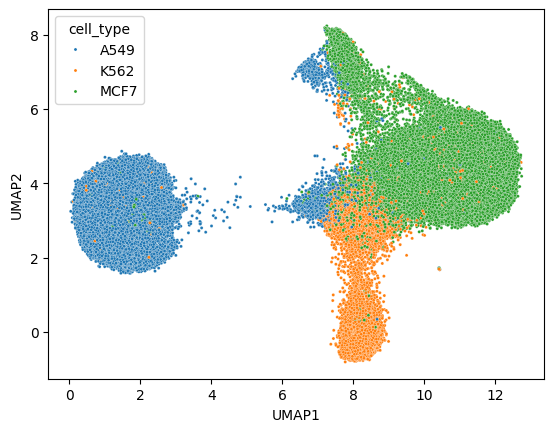

In [11]:
sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", hue="cell_type", s=5)


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

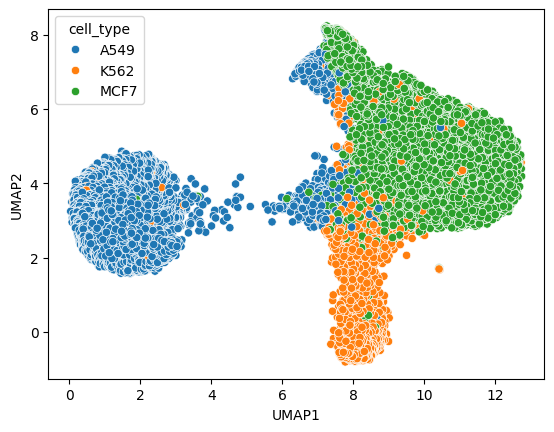

In [12]:
sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", hue="cell_type")
